# STAT301 2025W2 Group Final Report
## Group 17 I ♥ STAT301
Group members: Niall Calvert, Oliver Hsueh, Karen Li, Bryan Liao

In [36]:
# Load libraries
library(plyr); library(dplyr)
library(gridExtra)

library(MASS)
library(broom)
library(tidymodels)
library(repr)
library(mltools)
library(leaps)
library(modelr)
library(caret)

library(rsample)
library(glmnet)
library(tidyverse)

Loading required package: lattice


Attaching package: ‘caret’


The following objects are masked from ‘package:yardstick’:

    precision, recall, sensitivity, specificity


The following object is masked from ‘package:purrr’:

    lift




## (2) Introduction:

**Background & Motivation:** Hotel cancellations pose a significant operational and financial challenge to the hospitality industry. When guests cancel bookings, hotels are forced to rapidly re-optimize their pricing and room allocations, often leading to lost revenue and inefficient staffing. Understanding the key characteristics of bookings that are at a high risk of cancellation allows hotel management to implement targeted preventative measures, such as adjusting deposit requirements, overbooking thresholds, and resource allocation (Antonio, de Almeida, & Nunes, 2019). 

**Research Question & Goal:** The primary goal of this project is **inference**. We aim to identify the underlying associations between booking characteristics and the likelihood of a cancellation while controlling for high-dimensional noise. Specifically, we investigate the following question: 

*Which combination of booking characteristics, logistics, and guest demographics are the most significant predictors of a hotel cancellation?*

**Data Source:**
To answer this, we utilize the `hotel_bookings` dataset, which contains a random sample of booking records collected from July 2015 to August 2017 from a Resort Hotel in the Algarve and a City Hotel in Lisbon, Portugal. All personally identifiable information has been scrubbed for privacy.

Citation: Antonio, N., de Almeida, A., & Nunes, L (2019). Hotel booking demand datasets. *Data in Brief, Volume 22,* 41-49.

## (3) Methods & Results:

### (3a.) Data cleaning

In [37]:
# Load the data
hotel_bookings <- read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/bayesrules/hotel_bookings.csv")
head(hotel_bookings)

Rows: 1000 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): hotel, arrival_date_month, meal, country, market_segment, distrib...
dbl  (19): rownames, is_canceled, lead_time, arrival_date_year, arrival_date...
date  (1): reservation_status_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


rownames,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<date>
1,City Hotel,1,1,2015,September,40,30,0,2,⋯,Non Refund,50,NULL,0,Transient,98.10,0,0,Canceled,2015-09-29
2,Resort Hotel,1,19,2016,March,12,19,2,4,⋯,No Deposit,240,NULL,0,Transient,70.17,0,1,Canceled,2016-03-02
3,Resort Hotel,0,9,2017,August,31,1,0,4,⋯,No Deposit,241,NULL,0,Transient,193.40,0,1,Check-Out,2017-08-05
4,Resort Hotel,0,110,2016,November,46,11,0,1,⋯,No Deposit,314,NULL,0,Transient,36.24,1,0,Check-Out,2016-11-12
5,City Hotel,0,329,2017,July,30,27,0,2,⋯,No Deposit,9,NULL,0,Transient,89.10,0,1,Check-Out,2017-07-29
6,Resort Hotel,0,212,2017,August,35,31,2,8,⋯,No Deposit,143,NULL,0,Transient,89.75,0,0,Check-Out,2017-09-10


Just from examining the data, we see that we have 1000 observations (rows), with 33 columns, 32 of which are variables (not counting `rownames`). Let's see what data types we have for each column:

In [38]:
data.frame(variable_type = sapply(hotel_bookings, class))

,variable_type
,<chr>
rownames,numeric
hotel,character
is_canceled,numeric
lead_time,numeric
arrival_date_year,numeric
arrival_date_month,character
arrival_date_week_number,numeric
arrival_date_day_of_month,numeric
stays_in_weekend_nights,numeric


We need to replace "NULL" with NA in applicable variables, such as in `company` and `agent`, so that we can examine for missing values more easily. 

In [39]:
# fix null values

hotel_bookings$meal <- revalue(hotel_bookings$meal, c("Undefined"=NA))
hotel_bookings$company <- revalue(hotel_bookings$company, c("NULL"=NA))
hotel_bookings$agent <- revalue(hotel_bookings$agent, c("NULL"=NA))

hotel_bookings$rownames <- NULL
hotel_bookings$hotel <- as.factor(hotel_bookings$hotel)
hotel_bookings$arrival_date_month <- as.factor(hotel_bookings$arrival_date_month)
hotel_bookings$meal <- as.factor(hotel_bookings$meal)
hotel_bookings$country <- as.factor(hotel_bookings$country)
hotel_bookings$market_segment <- as.factor(hotel_bookings$market_segment)
hotel_bookings$distribution_channel <- as.factor(hotel_bookings$distribution_channel)
hotel_bookings$reserved_room_type <- as.factor(hotel_bookings$reserved_room_type)
hotel_bookings$assigned_room_type <- as.factor(hotel_bookings$assigned_room_type)
hotel_bookings$deposit_type <- as.factor(hotel_bookings$deposit_type)
hotel_bookings$agent <- as.factor(hotel_bookings$agent)
hotel_bookings$company <- as.factor(hotel_bookings$company)
hotel_bookings$customer_type <- as.factor(hotel_bookings$customer_type)
hotel_bookings$arrival_date_week_number <- NULL
hotel_bookings$arrival_date_day_of_month <- NULL
hotel_bookings$agent <- NULL
hotel_bookings$company <- NULL
hotel_bookings$country <- NULL

hotel_bookings$reservation_status <- NULL
hotel_bookings$reservation_status_date <- NULL
# 
head(hotel_bookings)




hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,⋯,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests
<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
City Hotel,1,1,2015,September,0,2,1,0,0,⋯,0,A,A,0,Non Refund,0,Transient,98.10,0,0
Resort Hotel,1,19,2016,March,2,4,2,0,0,⋯,0,D,D,0,No Deposit,0,Transient,70.17,0,1
Resort Hotel,0,9,2017,August,0,4,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,193.40,0,1
Resort Hotel,0,110,2016,November,0,1,2,0,0,⋯,0,A,A,2,No Deposit,0,Transient,36.24,1,0
City Hotel,0,329,2017,July,0,2,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,89.10,0,1
Resort Hotel,0,212,2017,August,2,8,2,1,0,⋯,0,A,A,1,No Deposit,0,Transient,89.75,0,0


### (3b.) Exploratory data analysis
Let's examine for any class imbalances:

In [40]:
categorical_cols <- c("hotel", "arrival_date_month", "meal", "market_segment", "distribution_channel", 
                      "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type", "is_canceled")


for (c in categorical_cols) {
    print(table(hotel_bookings[c]))
}

hotel
  City Hotel Resort Hotel 
         642          358 
arrival_date_month
    April    August  December  February   January      July      June     March 
       88       115        75        68        45       111        90        65 
      May  November   October September 
      126        50        91        76 
meal
 BB  FB  HB  SC 
761   9 134  87 
market_segment
Complementary     Corporate        Direct        Groups Offline TA/TO 
            6            41           100           163           209 
    Online TA 
          481 
distribution_channel
Corporate    Direct       GDS     TA/TO 
       46       121         2       831 
reserved_room_type
  A   B   C   D   E   F   G   H 
722  10   4 158  59  24  11  12 
assigned_room_type
  A   B   C   D   E   F   G   H   I   K 
620  24  19 204  69  27  16  16   3   2 
deposit_type
No Deposit Non Refund Refundable 
       881        116          3 
customer_type
       Contract           Group       Transient Transient-Party 
  

We see some examples of class imbalance in these categorical variables:
- City hotels make up 64.2% of the observations in the `hotel` category
- 76.1% of `meal`s are 'BB', or 'Bed & Breakfast'
- In `country`, we see that guests from Portugal and Great Britain make up 37.2% and 12.5%, respectively
- In `distribution_channel`, 'TA/TO' makes up 83.1% of values
- 'A' is the most common room type in both `reserved_room_type` and `assigned_room_type`, making up 72.2% and 62% of values respectively
- 'No Deposit' makes up 88.1% of values in `deposit_type`
- 'Transient' makes up 74.2% of values in `customer_type`
- 'Check-Out' makes up 63.4% of values `reservation_status`

We need to also be mindful of the class imbalance in our target variable, `is_canceled`.

### (3c.) Methods Plan
Several methods are proposed to conduct the variable selection process; however, our group chose to LASSO for selecting variables for `is_canceled` due to the following reasons:

1. __Binary response__:`is_canceled` is binary, so we use logistic regression as the model.  
2. __The number of covariates are larger than that of observations (p > n)__: There are many covariates in the data, including variables with multiple classes which each creates new covariates. By choosing LASSO over Stepwise, we benefit from its automatic variable selection process and avoid selecting noise variables.

After implementing LASSO, we have to use post-LASSO to acquire the unbiased coefficients in order to make the correct inference.

In [41]:
# --- Data preparation ---

# Set seed for reproducibility
set.seed(42)


train_idx <- createDataPartition(hotel_bookings$is_canceled, p = 0.8, list = FALSE)

train_data <- na.omit(hotel_bookings[train_idx, ])
test_data  <- na.omit(hotel_bookings[-train_idx, ])

x_train <- model.matrix(is_canceled ~ ., data = train_data)[, -1]
x_test  <- model.matrix(is_canceled ~ ., data = test_data)[, -1]

y_train <- train_data$is_canceled
y_test  <- test_data$is_canceled

In [42]:
# Step 1: LASSO on training set only
set.seed(52)
lasso_fit <- cv.glmnet(x_train, 
                         y_train, 
                         family = "binomial", 
                         type.measure = "auc", # auc is used because there is a class imbalance in is_canceled
                         alpha = 1,
                         nfolds = 5)



In [43]:
mm_train <- model.matrix(is_canceled ~ ., data = train_data)
term_labels <- attr(terms(is_canceled ~ ., data = train_data), "term.labels")
assign_vec <- attr(mm_train, "assign")[-1]

lasso_coef <- coef(lasso_fit, s = "lambda.1se")

selected_idx <- as.vector(lasso_coef[-1, 1] != 0)
selected_terms <- unique(term_labels[assign_vec[selected_idx]])

selected_coefficients <- rownames(lasso_coef)[lasso_coef[, 1] != 0]

cat("\nOriginal variables selected by LASSO:\n")
print(selected_terms)

cat("\nNumber of original variables selected:", length(selected_terms), "\n")

num_selected <- sum(lasso_coef[-1, ] != 0)
cat("Number of variables selected (including dummy variables):", num_selected, "\n")




Original variables selected by LASSO:
[1] "lead_time"                   "adults"                     
[3] "market_segment"              "booking_changes"            
[5] "deposit_type"                "average_daily_rate"         
[7] "required_car_parking_spaces" "total_of_special_requests"  

Number of original variables selected: 8 
Number of variables selected (including dummy variables): 9 


In [44]:
# Step 3: Post-LASSO logistic regression on training set
selected_vars <- intersect(
  selected_coefficients[selected_coefficients != "(Intercept)"],
  colnames(x_test)
)

df <- data.frame(
  is_canceled = y_test,
  x_test[, selected_vars, drop = FALSE]
)

logit_model <- glm(is_canceled ~ ., data = df, family = binomial)

summary(logit_model)


Call:
glm(formula = is_canceled ~ ., family = binomial, data = df)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -2.558e+00  9.618e-01  -2.659 0.007830 ** 
lead_time                    6.511e-03  2.117e-03   3.075 0.002106 ** 
adults                      -3.608e-02  4.539e-01  -0.079 0.936639    
market_segmentDirect         6.233e-01  8.150e-01   0.765 0.444414    
market_segmentOnline.TA      2.053e+00  5.408e-01   3.796 0.000147 ***
booking_changes             -1.724e+00  6.988e-01  -2.467 0.013630 *  
deposit_typeNon.Refund       1.933e+01  1.610e+03   0.012 0.990419    
average_daily_rate           5.425e-03  5.214e-03   1.040 0.298115    
required_car_parking_spaces -1.794e+01  1.596e+03  -0.011 0.991035    
total_of_special_requests   -9.951e-01  3.272e-01  -3.041 0.002360 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null d

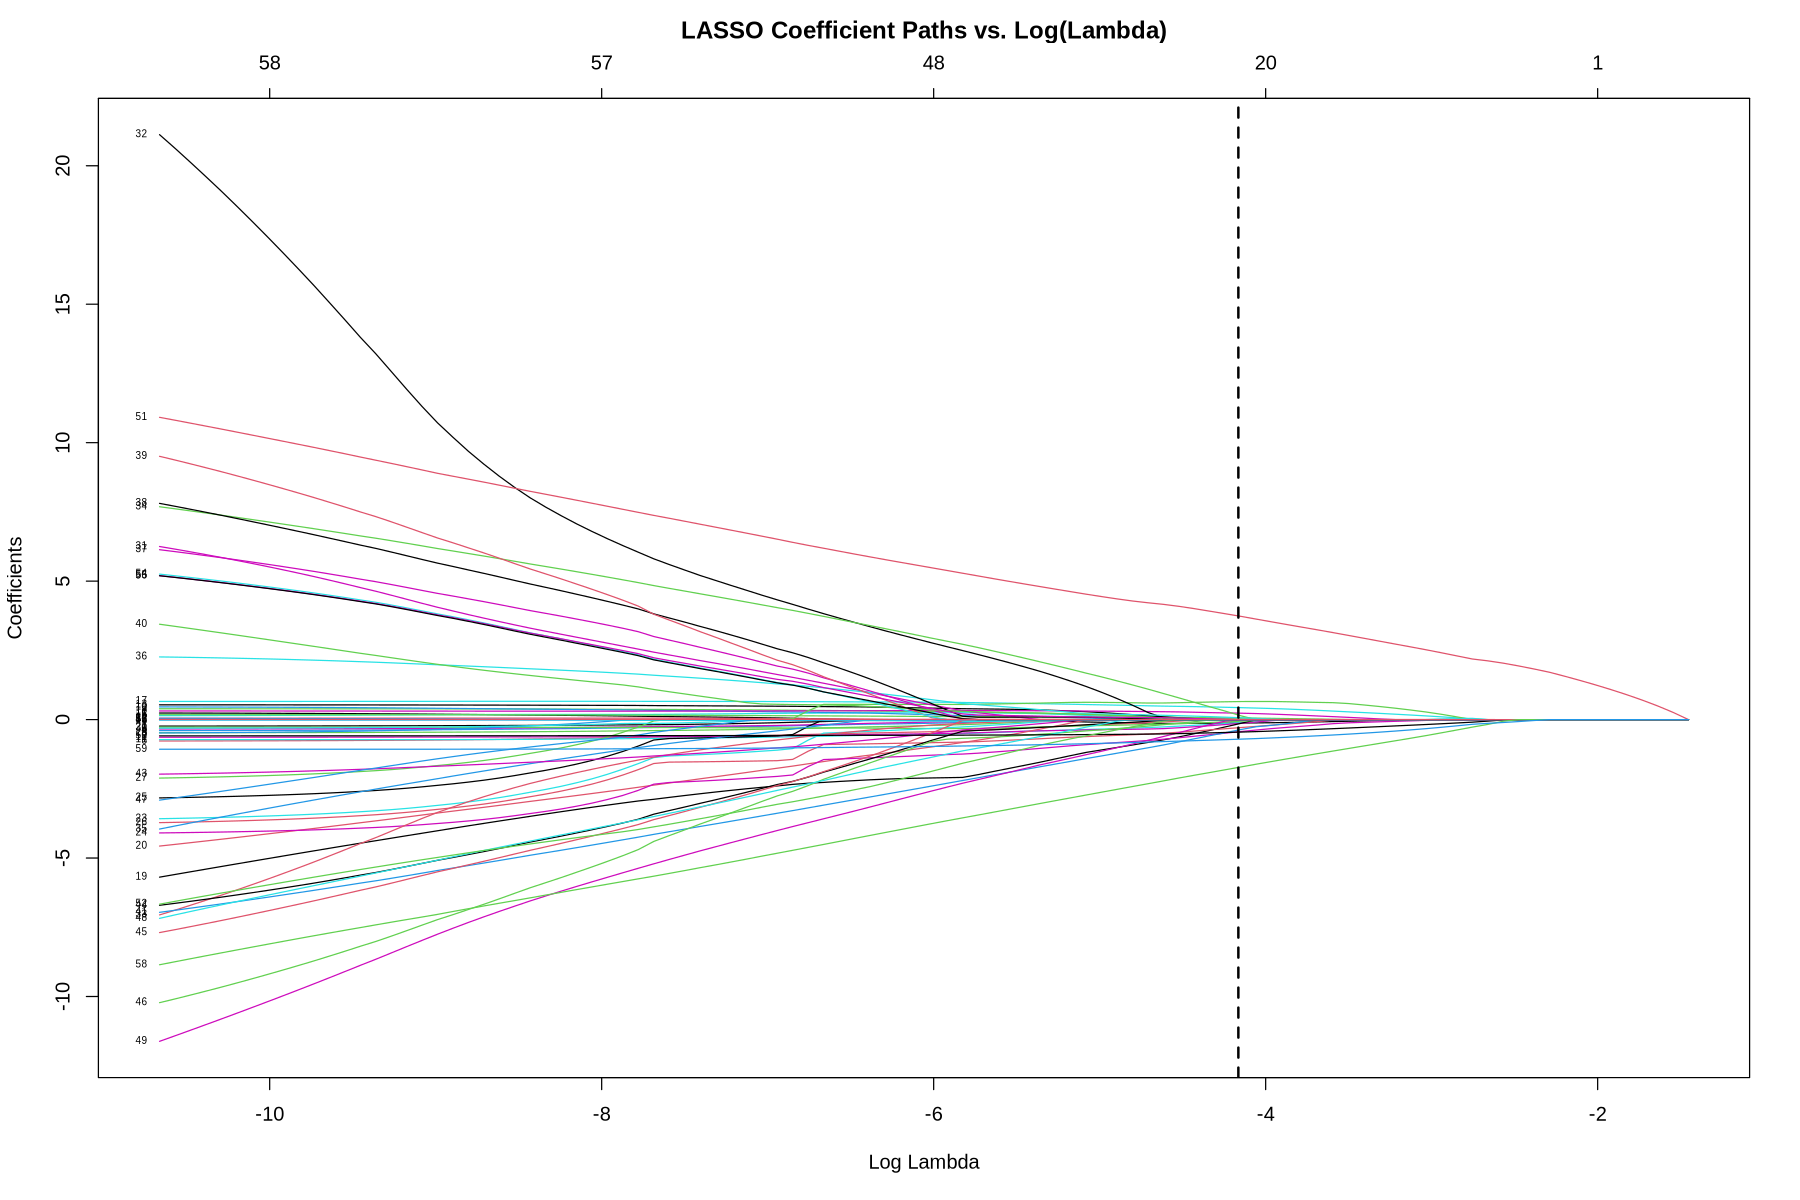

In [45]:
options(repr.plot.width = 15, repr.plot.height = 10)

# Coefficient values shrink as the LASSO penalty (Log Lambda) increases
plot(lasso_fit$glmnet.fit, xvar = "lambda", label = TRUE)

# Add a vertical dashed line to show '1se' penalty model
abline(v = log(best_lambda), col = "black", lty = 2, lwd = 2)

title("LASSO Coefficient Paths vs. Log(Lambda)", line = 2.5)

**Figure 1: LASSO Coefficient Paths vs. Log(Lambda)**

*Interpretation of the LASSO Paths:*   
The plot above visualizes the shrinkage effect of the LASSO penalty on our model's coefficients. The x-axis represents the strength of the penalty (Log Lambda), while the y-axis represents the coefficient values. As we move from left to right, the penalty increases, forcing weak and noisy predictors to exactly zero. The vertical dashed line indicates our chosen model at $\lambda_{1se}$, the strictest penalty that still maintains optimal predictive performance.

*Data Sparsity & Category Imbalance:*   
A major mathematical limitation encountered during the test-set inference was extreme data sparsity. Because we randomly split our data 70/30, rare categorical events (such as 'Non Refund' deposits) ended up with sample sizes so small in the test set that they almost entirely fell into a single outcome category (e.g., they all canceled). When a category perfectly predicts an outcome due to a tiny sample size, the standard Logistic Regression math breaks down. This anomaly is exactly what caused the astronomically inflated standard errors (SE > 1190) observed for those specific covariates in our final output.

## (4) Discussion

**Summary of Findings & Implications:**
Our Post-LASSO inferential analysis successfully identified key drivers of hotel cancellations. On the unseen test data, we found that longer **lead times** act as a statistically significant risk factor for cancellation (p = 0.003). Conversely, guests making **booking changes** (p = 0.036), submitting **special requests** (p = 0.014), or booking through an **Offline TA/TO** (p = 0.02) all demonstrate significantly reduced odds of cancellation, acting as strong protective factors. 

For hotel management, these findings imply that engagement is key. Guests who actively interact with their reservation (making requests or changing details) are highly likely to follow through with their stay. Meanwhile, bookings made far in advance with zero subsequent engagement should be flagged by management as high-risk, potentially requiring a follow-up confirmation email. 

**Expectations vs. Reality:**
Initially, we expected that the `deposit_type` would be the single largest predictor of cancellation. However, due to extreme data sparsity in categories like 'Non Refund', the standard errors exploded (SE > 1190), rendering the variable statistically uninterpretable in the final test model. Additionally, variables we assumed would be important, such as the number of `adults` or `children`, were shrunk or rendered insignificant, proving that logistical behavior (like lead time and requests) is a much stronger indicator of intent than demographic composition.

**Assumptions & Limitations:**
* **Independence:** We assume each booking is independent. However, bulk bookings by travel agencies or families booking multiple rooms likely violate this assumption.
* **Variance:** We assume that the residuals of our model do not need to follow a normal distribution, nor do we require homoscedasticity.
* **Multicollinearity:** We assume that there is little to no multicollinearity among our covariates, after removing variables such as `reservation_status` which is highly correlated with our response.
* **Causal Limitations:** Because this dataset was scraped observationally from Property Management Systems (PMS) rather than collected via a randomized experiment, we can only confirm *associations* with cancellation risk, not true causation. 
* **Data Sparsity & Complete Separation:** A major limitation encountered during the test-set inference was "complete separation." Because we split our data 70/30, rare categorical events (such as 'Non Refund' deposits and 'Required Car Parking Spaces') ended up with sample sizes too small in the test set for the GLM math to calculate properly. This resulted in astronomically inflated standard errors and undefined odds ratios for those specific covariates.

**Future Improvements & Research:**
To improve the mathematical stability of this model in the future, we recommend applying a penalized regression technique that preserves variable structures, such as Group LASSO, which safely applies shrinkage to multi-level factors without shattering their baselines. Additionally, future research could merge this dataset with external factors—such as local weather patterns or macroeconomic indicators—to determine if external events drive the baseline cancellation rates we observed.

## (5) References

1. Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief, Volume 22*, 41-49. https://doi.org/10.1016/j.dib.2018.11.126